# Analisis exploratorio - Art Institute of Chicago

Este notebook documenta el flujo de Ciencia de Datos solicitado en el taller: **extract -> raw -> transform -> EDA**.

La ingesta se realiza en `ingesta.py`, donde los documentos JSON crudos se almacenan en MongoDB. En este notebook se leen esos datos RAW, se seleccionan variables relevantes, se aplican transformaciones minimas y se generan insights y graficos.

## Resumen ejecutivo e indice

- **Fuente**: Art Institute of Chicago API.
- **Almacenamiento RAW**: MongoDB, base `taller4_db`, coleccion `raw_data`.
- **Precondicion**: ejecutar `python ingesta.py` antes de correr este notebook.
- **Objetivo del EDA**: analizar obras de arte por artista, fecha, departamento, tipo de obra, origen y medio.
- **Salidas esperadas**: validaciones, DataFrame limpio, minimo 5 insights y 3 graficos.

## 1. Configuracion y conexion a MongoDB

Se cargan las librerias y variables de entorno. Si no existe archivo `.env`, se usan los valores por defecto requeridos por la guia del taller.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pymongo import MongoClient

load_dotenv()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)

In [2]:
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
MONGO_DB = os.getenv("MONGO_DB", "taller4_db")
MONGO_COLLECTION = os.getenv("MONGO_COLLECTION", "raw_data")

client = MongoClient(MONGO_URI)
collection = client[MONGO_DB][MONGO_COLLECTION]

print(f"Conexion configurada para MongoDB: {MONGO_DB}.{MONGO_COLLECTION}")

Conexion configurada para MongoDB: taller4_db.raw_data


## 2. Validacion post-carga

Esta seccion verifica que la etapa de ingesta haya dejado suficientes documentos en MongoDB. Tambien revisa unicidad por `id`, que funciona como llave natural de la API.

In [3]:
total_documents = collection.count_documents({})
unique_api_ids = len(collection.distinct("id"))
duplicate_api_ids = total_documents - unique_api_ids
sample_document = collection.find_one({}, {"_id": 0})

validation_summary = pd.DataFrame({
    "metrica": ["documentos_raw", "ids_unicos", "posibles_duplicados"],
    "valor": [total_documents, unique_api_ids, duplicate_api_ids],
})

validation_summary

,metrica,valor
0,documentos_raw,100
1,ids_unicos,100
2,posibles_duplicados,0


In [4]:
if total_documents < 100:
    raise ValueError("La coleccion debe tener minimo 100 documentos. Ejecuta primero python ingesta.py")

if duplicate_api_ids != 0:
    raise ValueError("Se detectaron ids duplicados. Revisa la logica de upsert en ingesta.py")

print("Validacion correcta: hay minimo 100 documentos y no se detectan ids duplicados.")

Validacion correcta: hay minimo 100 documentos y no se detectan ids duplicados.


In [5]:
sample_fields = sorted(sample_document.keys()) if sample_document else []
print("Campos disponibles en un documento RAW de ejemplo:")
print(sample_fields[:40])

Campos disponibles en un documento RAW de ejemplo:
['alt_artist_ids', 'alt_classification_ids', 'alt_image_ids', 'alt_material_ids', 'alt_style_ids', 'alt_subject_ids', 'alt_technique_ids', 'alt_titles', 'api_link', 'api_model', 'artist_display', 'artist_id', 'artist_ids', 'artist_title', 'artist_titles', 'artwork_type_id', 'artwork_type_title', 'boost_rank', 'catalogue_display', 'category_ids', 'category_titles', 'classification_id', 'classification_ids', 'classification_title', 'classification_titles', 'color', 'colorfulness', 'copyright_notice', 'credit_line', 'date_display', 'date_end', 'date_qualifier_id', 'date_qualifier_title', 'date_start', 'department_id', 'department_title', 'description', 'dimensions', 'dimensions_detail', 'document_ids']


## 3. Carga del dato RAW en Pandas

MongoDB conserva el documento original de la API. Pandas se usa para crear una vista tabular que facilite el analisis, sin modificar la coleccion RAW.

In [6]:
records = list(collection.find({}, {"_id": 0}))
raw_df = pd.DataFrame(records)

print(f"Filas RAW: {raw_df.shape[0]}")
print(f"Columnas RAW: {raw_df.shape[1]}")
raw_df.head(3)

Filas RAW: 100
Columnas RAW: 99


,id,api_model,api_link,is_boosted,title,alt_titles,thumbnail,main_reference_number,has_not_been_viewed_much,boost_rank,date_start,date_end,date_display,date_qualifier_title,date_qualifier_id,artist_display,place_of_origin,description,short_description,dimensions,dimensions_detail,medium_display,inscriptions,credit_line,catalogue_display,...,subject_ids,subject_titles,material_id,alt_material_ids,material_ids,material_titles,technique_id,alt_technique_ids,technique_ids,technique_titles,theme_titles,image_id,alt_image_ids,document_ids,sound_ids,video_ids,text_ids,section_ids,section_titles,site_ids,suggest_autocomplete_all,source_updated_at,updated_at,timestamp,suggest_autocomplete_boosted
0,80487,artworks,https://api.artic.edu/api/v1/artworks/80487,False,Arbor Day,None,"{'lqip': 'data:image/gif;base64,R0lGODlhCAAFAP...",1921.103,True,None,1920.0,1920.0,1920,,NaN,"Eugene Francis Savage (American, 1883–1966)",United States,None,None,115.3 × 88 cm (45 3/8 × 35 in.),"[{'depth': None, 'width': 88, 'height': 115, '...",Oil on panel,"Signed recto, bottom-left corner, on shrub, in...",Friends of American Art Collection,None,...,[],[],TM-2451,[TM-3644],"[TM-2451, TM-3644]","[oil paint (paint), panel (wood)]",None,[],[],[],[],9157e82e-0ef5-329d-85a8-696dfe3b045e,[],[],[],[],[],[],[],[],"[{'input': ['1921.103'], 'contexts': {'groupin...",2026-05-15T11:03:41-05:00,2026-06-05T22:13:05-05:00,2026-06-05T22:13:18-05:00,NaN
1,65151,artworks,https://api.artic.edu/api/v1/artworks/65151,False,Linear,None,"{'lqip': 'data:image/gif;base64,R0lGODlhAgAFAP...",1986.1034,True,None,1950.0,1959.0,1950s,Made,4.0,"Designed by Joseph R. Bobrowicz (American, bor...",Pennsylvania,None,None,318.8 × 119.7 cm (125 1/2 × 47 1/8 in.); Repea...,"[{'depth': None, 'width': 119, 'height': 318, ...","Silk and cotton, plain weave; screen printed",None,Gift of Mr. and Mrs. Joseph R. Bobrowicz,None,...,[],[],None,[],[],[],None,[],[],[],[],f3cf108f-2d2c-37d2-1ff3-f8d34f232e62,[3034794b-9a40-c78e-3638-dec1e0772c8a],[],[],[],[],[],[],[],"[{'input': ['1986.1034'], 'contexts': {'groupi...",2024-04-25T16:14:21-05:00,2026-06-05T22:12:53-05:00,2026-06-05T22:13:18-05:00,NaN
2,90981,artworks,https://api.artic.edu/api/v1/artworks/90981,False,3-D Squares,None,"{'lqip': 'data:image/gif;base64,R0lGODlhAgAFAP...",1989.532,True,None,1989.0,1989.0,1989,Made,4.0,"Bobbi Shortlidge (American, born 1944)\nUnited...",Illinois,None,None,168.9 × 96 cm (105 7/8 × 37 3/4 in.),"[{'depth': None, 'width': 96, 'height': 168, '...","Wool, plain weave; double cloth",None,Gift of Mrs. Bobbi Shortlidge,None,...,[],[],TM-2581,[],[TM-2581],[wool (textile)],None,[],[],[],[],a2eb6847-f90c-06d0-46dd-1f5b8e7c7813,"[e28c5c37-e054-94d4-7af9-cd2899c6a650, f2a155c...",[],[],[],[],[],[],[],"[{'input': ['1989.532'], 'contexts': {'groupin...",2026-04-13T18:19:07-05:00,2026-06-05T22:12:43-05:00,2026-06-05T22:13:18-05:00,NaN


## 4. Seleccion de variables para el EDA

A partir del documento crudo se seleccionan variables con valor analitico. Esta es la frontera entre el dato RAW no relacional y una tabla curada para exploracion.

In [7]:
variable_dictionary = pd.DataFrame([
    {"variable": "id", "descripcion": "Identificador unico de la obra en la API."},
    {"variable": "title", "descripcion": "Titulo de la obra."},
    {"variable": "artist_title", "descripcion": "Nombre del artista o autor registrado."},
    {"variable": "date_start", "descripcion": "Anio inicial asociado a la obra."},
    {"variable": "department_title", "descripcion": "Departamento del museo al que pertenece la obra."},
    {"variable": "artwork_type_title", "descripcion": "Tipo o categoria de obra."},
    {"variable": "place_of_origin", "descripcion": "Lugar de origen registrado."},
    {"variable": "medium_display", "descripcion": "Medio o tecnica de la obra."},
])

variable_dictionary

,variable,descripcion
0,id,Identificador unico de la obra en la API.
1,title,Titulo de la obra.
2,artist_title,Nombre del artista o autor registrado.
3,date_start,Anio inicial asociado a la obra.
4,department_title,Departamento del museo al que pertenece la obra.
5,artwork_type_title,Tipo o categoria de obra.
6,place_of_origin,Lugar de origen registrado.
7,medium_display,Medio o tecnica de la obra.


In [8]:
selected_columns = [
    "id",
    "title",
    "artist_title",
    "date_start",
    "department_title",
    "artwork_type_title",
    "place_of_origin",
    "medium_display",
]

missing_columns = [column for column in selected_columns if column not in raw_df.columns]
if missing_columns:
    raise KeyError(f"Faltan columnas esperadas en el RAW: {missing_columns}")

df = raw_df[selected_columns].copy()
df.head()

,id,title,artist_title,date_start,department_title,artwork_type_title,place_of_origin,medium_display
0,80487,Arbor Day,Eugene Francis Savage,1920.0,Arts of the Americas,Painting,United States,Oil on panel
1,65151,Linear,Joseph R. Bobrowicz,1950.0,Textiles,Textile,Pennsylvania,"Silk and cotton, plain weave; screen printed"
2,90981,3-D Squares,Bobbi Shortlidge,1989.0,Textiles,Textile,Illinois,"Wool, plain weave; double cloth"
3,77688,Peacock Weather Vane,Artist unknown,1800.0,Arts of the Americas,Sculpture,Pennsylvania,Iron
4,65133,Panel (Upholstery Fabric),Yvonne Palmer Pacanovsky Bobrowicz,1951.0,Textiles,Textile,Pennsylvania,"Cotton, rayon, and polyolefin, float weave"


## 5. Transformacion minima y limpieza

La limpieza se limita al DataFrame de analisis. Se normalizan textos vacios, se convierten fechas a numerico y se crean dos variables auxiliares para mejorar los insights.

In [9]:
unknown_values = {
    "title": "Titulo no identificado",
    "artist_title": "Artista no identificado",
    "department_title": "Sin departamento",
    "artwork_type_title": "Sin tipo",
    "place_of_origin": "Origen no identificado",
    "medium_display": "Medio no identificado",
}

for column, replacement in unknown_values.items():
    df[column] = df[column].fillna(replacement).astype(str).str.strip()
    df.loc[df[column].eq(""), column] = replacement

df["date_start"] = pd.to_numeric(df["date_start"], errors="coerce")

def classify_century(year):
    if pd.isna(year):
        return "Fecha no identificada"
    if year <= 0:
        return "Antes de era comun"
    century = int((year - 1) // 100 + 1)
    return f"Siglo {century}"

df["century"] = df["date_start"].apply(classify_century)
unknown_artist_labels = {
    "artista no identificado",
    "artist unknown",
    "unknown artist",
    "unknown",
}
df["has_identified_artist"] = ~df["artist_title"].str.lower().isin(unknown_artist_labels)
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

df.head()

,id,title,artist_title,date_start,department_title,artwork_type_title,place_of_origin,medium_display,century,has_identified_artist
0,80487,Arbor Day,Eugene Francis Savage,1920.0,Arts of the Americas,Painting,United States,Oil on panel,Siglo 20,True
1,65151,Linear,Joseph R. Bobrowicz,1950.0,Textiles,Textile,Pennsylvania,"Silk and cotton, plain weave; screen printed",Siglo 20,True
2,90981,3-D Squares,Bobbi Shortlidge,1989.0,Textiles,Textile,Illinois,"Wool, plain weave; double cloth",Siglo 20,True
3,77688,Peacock Weather Vane,Artist unknown,1800.0,Arts of the Americas,Sculpture,Pennsylvania,Iron,Siglo 18,False
4,65133,Panel (Upholstery Fabric),Yvonne Palmer Pacanovsky Bobrowicz,1951.0,Textiles,Textile,Pennsylvania,"Cotton, rayon, and polyolefin, float weave",Siglo 20,True


## 6. Inspeccion basica

Se revisan primeras filas, tipos de datos y nulos. Esta parte responde directamente al requisito de inspeccion del taller.

In [10]:
df.head(10)

,id,title,artist_title,date_start,department_title,artwork_type_title,place_of_origin,medium_display,century,has_identified_artist
0,80487,Arbor Day,Eugene Francis Savage,1920.0,Arts of the Americas,Painting,United States,Oil on panel,Siglo 20,True
1,65151,Linear,Joseph R. Bobrowicz,1950.0,Textiles,Textile,Pennsylvania,"Silk and cotton, plain weave; screen printed",Siglo 20,True
2,90981,3-D Squares,Bobbi Shortlidge,1989.0,Textiles,Textile,Illinois,"Wool, plain weave; double cloth",Siglo 20,True
3,77688,Peacock Weather Vane,Artist unknown,1800.0,Arts of the Americas,Sculpture,Pennsylvania,Iron,Siglo 18,False
4,65133,Panel (Upholstery Fabric),Yvonne Palmer Pacanovsky Bobrowicz,1951.0,Textiles,Textile,Pennsylvania,"Cotton, rayon, and polyolefin, float weave",Siglo 20,True
5,87741,Bracket (one of two),Artista no identificado,1730.0,Applied Arts of Europe,Furniture,France,"Wood, possibly oak, carved and gilded",Siglo 18,False
6,48299,"Place de la Trinité, Paris, small plate",Jean-François Rafaëlli,1893.0,Prints and Drawings,Print,France,Etching with drypoint and roulette from two pl...,Siglo 19,True
7,26930,Bracket (one of two),Artista no identificado,1730.0,Applied Arts of Europe,Furniture,France,"Wood, possibly oak, carved and gilded",Siglo 18,False
8,24554,Pair of Eight Light Candelabra,"Clodion, (Claude Michel)",1780.0,Applied Arts of Europe,Metalwork,France,Patinated and gilded bronze,Siglo 18,True
9,24552,Pair of Candelabra,In the manner of Pierre Gouthière,1784.0,Applied Arts of Europe,Metalwork,France,Bronze gilt,Siglo 18,True


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   title                  100 non-null    object 
 2   artist_title           100 non-null    object 
 3   date_start             99 non-null     float64
 4   department_title       100 non-null    object 
 5   artwork_type_title     100 non-null    object 
 6   place_of_origin        100 non-null    object 
 7   medium_display         100 non-null    object 
 8   century                100 non-null    object 
 9   has_identified_artist  100 non-null    bool   
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 7.3+ KB


In [12]:
null_summary = (
    df.isnull()
    .sum()
    .reset_index(name="nulos")
    .rename(columns={"index": "variable"})
)
null_summary["porcentaje"] = (null_summary["nulos"] / len(df) * 100).round(2)
null_summary

,variable,nulos,porcentaje
0,id,0,0.0
1,title,0,0.0
2,artist_title,0,0.0
3,date_start,1,1.0
4,department_title,0,0.0
5,artwork_type_title,0,0.0
6,place_of_origin,0,0.0
7,medium_display,0,0.0
8,century,0,0.0
9,has_identified_artist,0,0.0


In [13]:
sanity_checks = pd.DataFrame({
    "revision": [
        "filas_en_dataframe",
        "columnas_en_dataframe",
        "ids_duplicados",
        "artistas_identificados",
        "anio_minimo",
        "anio_maximo",
    ],
    "valor": [
        len(df),
        df.shape[1],
        df.duplicated(subset=["id"]).sum(),
        int(df["has_identified_artist"].sum()),
        int(df["date_start"].min()) if df["date_start"].notna().any() else "No disponible",
        int(df["date_start"].max()) if df["date_start"].notna().any() else "No disponible",
    ],
})

sanity_checks

,revision,valor
0,filas_en_dataframe,100
1,columnas_en_dataframe,10
2,ids_duplicados,0
3,artistas_identificados,79
4,anio_minimo,-2055
5,anio_maximo,2024


## 7. Insights numericos y conteos

Los siguientes resultados resumen patrones relevantes de la muestra. Se calculan mas de 5 para tener material suficiente al redactar el PDF final.

In [14]:
total_obras = len(df)
artistas_unicos = df["artist_title"].nunique()
artistas_identificados = int(df["has_identified_artist"].sum())
porcentaje_artistas_identificados = artistas_identificados / total_obras * 100

department_counts = df["department_title"].value_counts()
type_counts = df["artwork_type_title"].value_counts()
origin_counts = df["place_of_origin"].value_counts()
century_counts = df["century"].value_counts()

valid_years = df["date_start"].dropna()
anio_min = int(valid_years.min()) if not valid_years.empty else "No disponible"
anio_max = int(valid_years.max()) if not valid_years.empty else "No disponible"

insights = [
    f"El conjunto analizado contiene {total_obras} obras de arte.",
    f"Hay {artistas_unicos} artistas o autores distintos en los registros seleccionados.",
    f"El {porcentaje_artistas_identificados:.1f}% de las obras tiene artista identificado.",
    f"El departamento con mas obras es '{department_counts.idxmax()}', con {department_counts.max()} registros.",
    f"El tipo de obra mas frecuente es '{type_counts.idxmax()}', con {type_counts.max()} registros.",
    f"El lugar de origen mas frecuente es '{origin_counts.idxmax()}', con {origin_counts.max()} registros.",
    f"El siglo mas frecuente es '{century_counts.idxmax()}', con {century_counts.max()} obras.",
    f"Las fechas de inicio de las obras van desde {anio_min} hasta {anio_max}.",
]

for number, insight in enumerate(insights, start=1):
    print(f"{number}. {insight}")

1. El conjunto analizado contiene 100 obras de arte.
2. Hay 61 artistas o autores distintos en los registros seleccionados.
3. El 79.0% de las obras tiene artista identificado.
4. El departamento con mas obras es 'Applied Arts of Europe', con 19 registros.
5. El tipo de obra mas frecuente es 'Glass', con 15 registros.
6. El lugar de origen mas frecuente es 'United States', con 19 registros.
7. El siglo mas frecuente es 'Siglo 20', con 48 obras.
8. Las fechas de inicio de las obras van desde -2055 hasta 2024.


## 8. Grafico de torta obligatorio

El grafico muestra la proporcion de obras por departamento. Para mantenerlo legible, se agrupan los departamentos menos frecuentes en `Otros`.

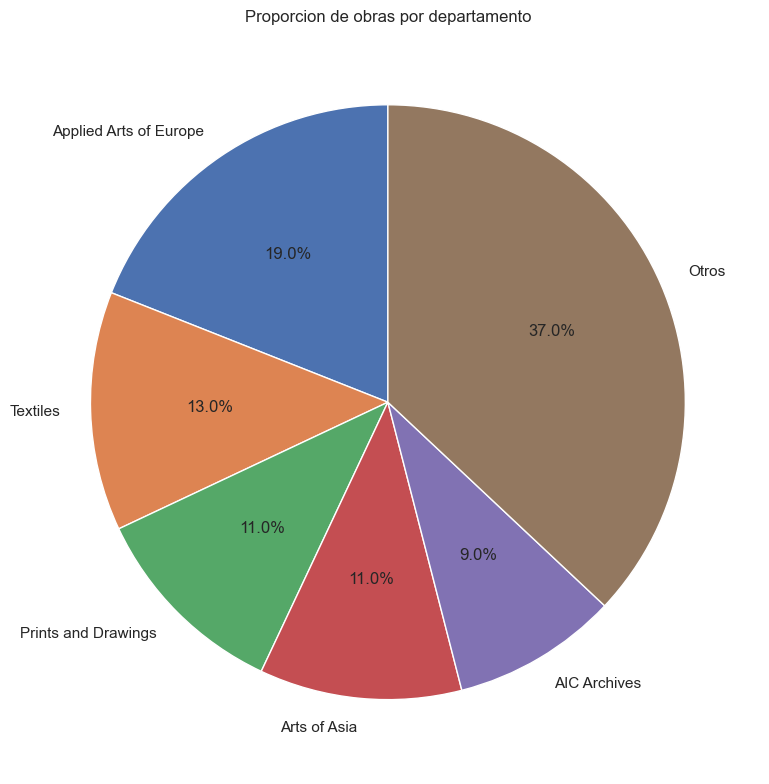

In [15]:
department_counts = df["department_title"].value_counts()
top_departments = department_counts.head(5)
other_departments = department_counts.iloc[5:].sum()

pie_data = top_departments.copy()
if other_departments > 0:
    pie_data.loc["Otros"] = other_departments

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=90)
plt.title("Proporcion de obras por departamento")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Grafico libre 1: barras por tipo de obra

Este grafico permite identificar concentracion por categorias artisticas.

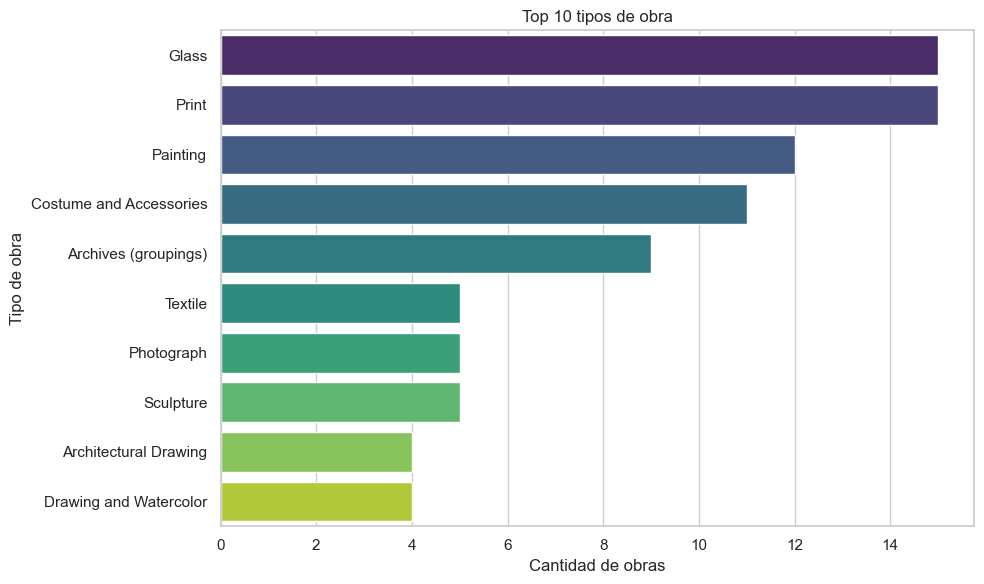

In [16]:
type_counts = df["artwork_type_title"].value_counts().head(10)

sns.barplot(
    x=type_counts.values,
    y=type_counts.index,
    hue=type_counts.index,
    palette="viridis",
    legend=False,
)
plt.title("Top 10 tipos de obra")
plt.xlabel("Cantidad de obras")
plt.ylabel("Tipo de obra")
plt.tight_layout()
plt.show()

## 10. Grafico libre 2: distribucion de fechas

El histograma ayuda a observar en que periodos se concentran las obras de la muestra.

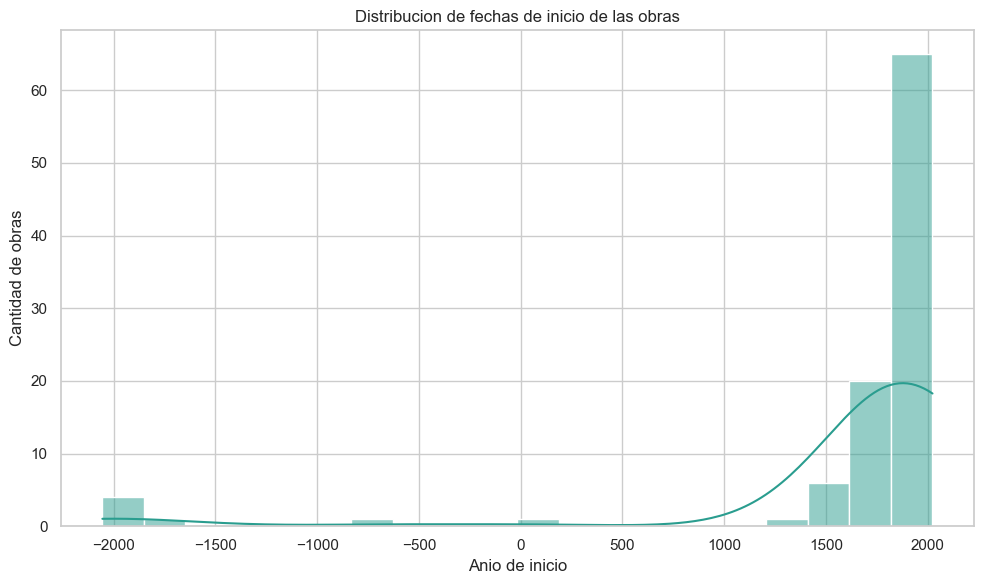

In [17]:
valid_years = df["date_start"].dropna()

sns.histplot(valid_years, bins=20, kde=True, color="#2a9d8f")
plt.title("Distribucion de fechas de inicio de las obras")
plt.xlabel("Anio de inicio")
plt.ylabel("Cantidad de obras")
plt.tight_layout()
plt.show()

## 11. Criterios de calidad del EDA

- **Completitud**: se valida que existan al menos 100 documentos en MongoDB.
- **Exactitud operativa**: se revisa unicidad por `id` para evitar duplicados.
- **Consistencia**: textos vacios y nulos se normalizan en el DataFrame de analisis.
- **Trazabilidad**: la coleccion `raw_data` conserva el JSON original de la API.
- **Documentacion**: cada etapa del notebook explica que se hace y por que se hace.

## 12. Limitaciones y proximos pasos

La muestra depende de la paginacion y del orden de respuesta de la API. Para un analisis mas profundo se podria aumentar `TARGET_RECORDS`, analizar mas campos del JSON original o comparar obras por periodos historicos, artistas y departamentos especificos.